In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# nat_gas_2000-2025_Trade_Data (Separate CSVs)
folder_name = "nat_gas_2000-2025_Trade_data"
year_list = list(range(2000, 2025)) 
df_check = pd.concat([pd.read_csv(f"{folder_name}/{y}") for y in year_list], ignore_index=True)
df = df_check.copy()

# Ensure period is datetime
if df["period"].dtype != "datetime64[ns]":
    df["period"] = pd.to_datetime(df["period"].astype(str), format="%Y%m", errors="coerce")

In [3]:
# Makind a standard column list
std_col = [
    "period","refYear","refMonth",
    "reporterCode","reporterDesc",
    "partnerCode","partnerDesc",
    "flowCode","flowDesc",
    "cmdCode","cmdDesc",
    "primaryValue",
    "netWgt",
    "qty","qtyUnitCode","qtyUnitAbbr",
    "altQty","altQtyUnitCode"

]

std_col = [i for i in std_col if i in df.columns]
df1 = df[std_col].copy()

df1.head(5)

,period,refYear,refMonth,reporterCode,reporterDesc,partnerCode,partnerDesc,flowCode,flowDesc,cmdCode,cmdDesc,primaryValue,netWgt,qty,qtyUnitCode,qtyUnitAbbr,altQty,altQtyUnitCode
0,2000-01-01,2000,1,600,NaN,0,NaN,M,NaN,271111,NaN,4090.000,26000.0,26000.0,8,NaN,26000.0,8
1,2000-01-01,2000,1,600,NaN,0,NaN,M,NaN,271111,NaN,4090.000,26000.0,26000.0,8,NaN,26000.0,8
2,2000-01-01,2000,1,600,NaN,76,NaN,M,NaN,271111,NaN,4090.000,26000.0,26000.0,8,NaN,26000.0,8
3,2000-01-01,2000,1,600,NaN,76,NaN,M,NaN,271111,NaN,4090.000,26000.0,26000.0,8,NaN,26000.0,8
4,2000-01-01,2000,1,579,NaN,0,NaN,X,NaN,271111,NaN,29235.494,32000.0,32000.0,8,NaN,32000.0,8


In [4]:
# Basic Checks
print("Rows:", len(df1))
print("Date range:", df1["period"].min(), "to", df1["period"].max())
print("Unique reporters:", df1["reporterCode"].nunique() if "reporterCode" in df1 else None)
print("Unique partners:", df1["partnerCode"].nunique() if "partnerCode" in df1 else None)

# Missing Data (overall)
miss_values = (df1.isna().mean() * 100).sort_values(ascending=False)
print("\nMissingness rate (%) — overall:\n", miss_values)

# Missingness by year (To check for rough unit price estimation = netWgt/qty)
if "ref_year" in df1:
    cols_check = [i for i in ["primaryValue","netWgt","qty"] if i in df1.columns]
    miss_by_year = (
    df1.groupby("refYear")[cols_check].mean()
    .mul(100)
    .round(2)
    )

Rows: 491806
Date range: 2000-01-01 00:00:00 to 2024-12-01 00:00:00
Unique reporters: 157
Unique partners: 223

Missingness rate (%) — overall:
 partnerDesc       100.000000
reporterDesc      100.000000
qtyUnitAbbr       100.000000
cmdDesc           100.000000
flowDesc          100.000000
netWgt              1.893430
qty                 0.972538
altQty              0.972538
refYear             0.000000
period              0.000000
cmdCode             0.000000
flowCode            0.000000
reporterCode        0.000000
partnerCode         0.000000
refMonth            0.000000
primaryValue        0.000000
qtyUnitCode         0.000000
altQtyUnitCode      0.000000
dtype: float64


In [ ]:
# Quantity unit distribution (to see if qty is comparable)
if "qtyUnitAbbr" in df1:
    print("\nTop qty units:\n", df1["qtyUnitAbbr"].value_counts(dropna=False).head(15))

# How many rows can support unit-value via netWgt?
if "netWgt" in df1 and "primaryValue" in df1:
    usable_netwgt = df1["netWgt"].notna() & (df1["netWgt"] > 0) & df1["primaryValue"].notna()
    print("\nRows usable for unit-value using netWgt:", usable_netwgt.sum(), f"({usable_netwgt.mean()*100:.2f}%)")


Top qty units:
 qtyUnitAbbr
NaN    491806
Name: count, dtype: int64

Rows usable for unit-value using netWgt: 468477 (95.26%)


## Global trade evolution (Basic Trend Analysis)

Goal: Establish baseline trends in global natural gas trade.  
We aggregate total imports vs exports and compare LNG vs gaseous gas using annual and **monthly time series.


In [10]:
# Required columns check
req_col = ["period","refYear","refMonth","flowCode","cmdCode","primaryValue","netWgt"]
missing = [i for i in req_col if i not in df1.columns]
if missing:
    raise ValueError(f"df1 is missing columns: {missing}")

# Flow Type Check - Whether Import or Export
df2 = df1.copy()
df2["flow_type"] = np.where(
    df2["flowCode"].astype(str).str.contains("M", na=False), "Import",
    np.where(df2["flowCode"].astype(str).str.contains("X", na=False), "Export", "Other")
)

# Keeping only Import and Export right now
df2 = df2[df2["flow_type"].isin(["Import", "Export"])].copy()

# Commodity: LNG vs Gaseous, '271111', Natural gas, liquefied', 271121' Natural gas, gaseous
df2["product"] = np.select(
    [df2["cmdCode"].astype(str).eq("271111"),
     df2["cmdCode"].astype(str).eq("271121")],
     ["LNG (271111)", "Gaseous NG (271121)"],
     default="Other"
)
# Keep only our two products
df2 = df2[df2["product"].isin(["LNG (271111)", "Gaseous NG (271121)"])].copy()

df2["primaryValue"] = pd.to_numeric(df2["primaryValue"], errors="coerce")
df2["netWgt"] = pd.to_numeric(df2["netWgt"], errors="coerce")

df2 = df2[df2["primaryValue"].notna()].copy()
df2 = df2[df2["primaryValue"] >= 0].copy()

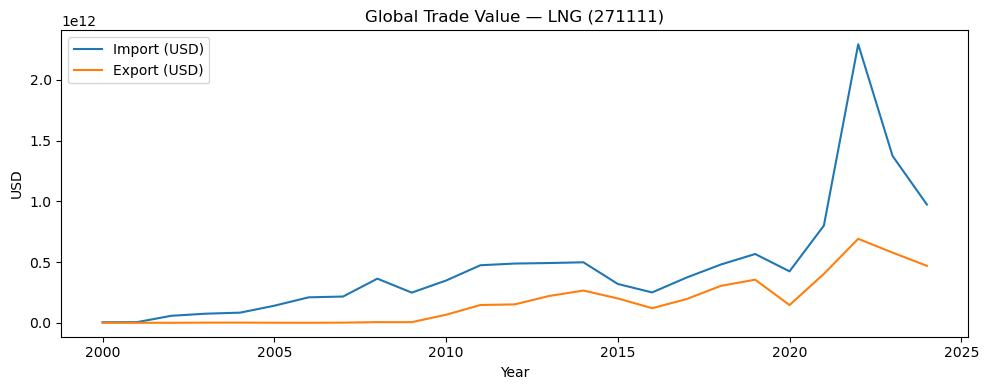

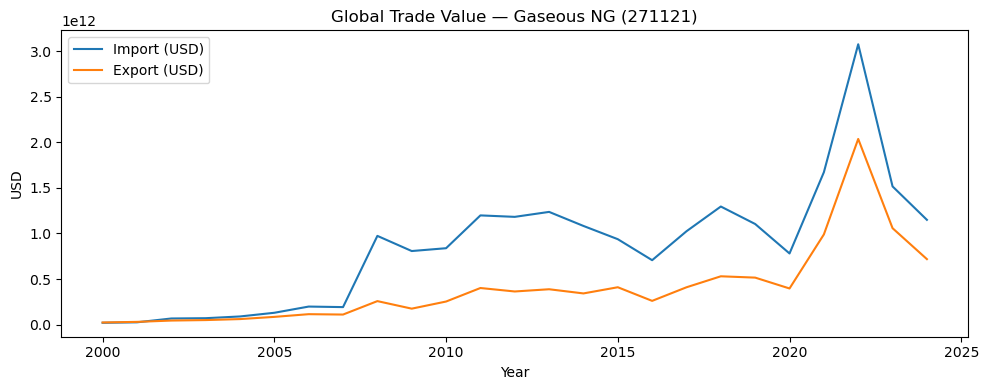

In [ ]:
# Annual global trends (USD): imports, exports
annual_val = (
    df2.groupby(["refYear","flow_type","product"], as_index=False)
       .agg(value_usd=("primaryValue","sum"))
)

# Pivot to get Import and Export on the same row (per year, per product)
annual_val_piv = (
    annual_val.pivot_table(index=["refYear","product"], columns="flow_type", values="value_usd", fill_value=0)
              .reset_index()
)

annual_val_piv["net_trade_usd"] = annual_val_piv.get("Export", 0) - annual_val_piv.get("Import", 0)

annual_val_piv.head()

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = annual_val_piv[annual_val_piv["product"] == prod].sort_values("refYear")

    plt.figure(figsize=(10,4))
    plt.plot(tmp["refYear"], tmp.get("Import", 0), label="Import (USD)")
    plt.plot(tmp["refYear"], tmp.get("Export", 0), label="Export (USD)")
    plt.title(f"Global Trade Value — {prod}")
    plt.xlabel("Year")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()





   """

   Global trade values are computed as the sum of reported import/export values across all reporting countries. These figures reflect trade flow intensity rather than net global expenditure and may include double counting due to re-exports and asymmetric reporting. As we move forward in the analysis we will start seeing more specific patterns.
    Please find the explanation of the above plots:
      1 - The LNG market is consistent but in 2022 we see a sharp increase in trade value, reflecting a sharp price shock rather than proportional growth in traded volumes (as we will see in plots below).
      2 - Overall for the Gaseous NG we notice a similar pattern. Additionally, we also notice that Gaseous NG has larger absolute values than LNG. 
          We also notice a sharper decline as compared to LNG, since the market is more rigid and geographically constarined. The faster decline in values suggests structural loss of pipeline routes (Russia-EU)
    """

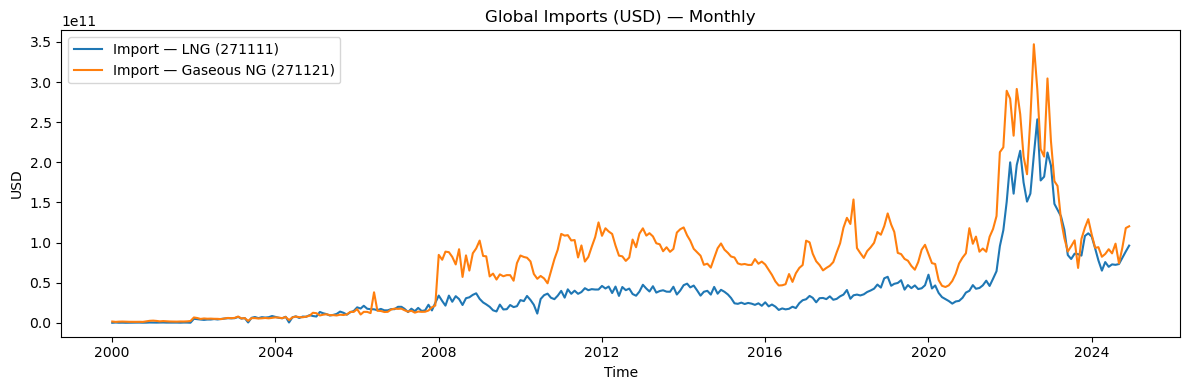

In [ ]:
# Monthly Global Trends

"""
    This is supposed to show the monthly global trends, but since the data is quite long, its gets clustered.
    We do see some seasonal efffects, which i will expand more on during the seasonality analysis. This code will mainly be used then.
"""
monthly_val = (
    df2.groupby(["period","flow_type","product"], as_index=False)
       .agg(value_usd=("primaryValue","sum"))
)
monthly_val_wide = (
    monthly_val.pivot_table(index=["period","product"], columns="flow_type", values="value_usd", fill_value=0)
               .reset_index()
)
monthly_val_wide["net_trade_usd"] = monthly_val_wide.get("Export", 0) - monthly_val_wide.get("Import", 0)

monthly_val_wide.head()

plt.figure(figsize=(12,4))
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = monthly_val_wide[monthly_val_wide["product"] == prod].sort_values("period")
    plt.plot(tmp["period"], tmp.get("Import", 0), label=f"Import — {prod}")

plt.title("Global Imports (USD) — Monthly")
plt.xlabel("Time")
plt.ylabel("USD")
plt.legend()
plt.tight_layout()
plt.show()




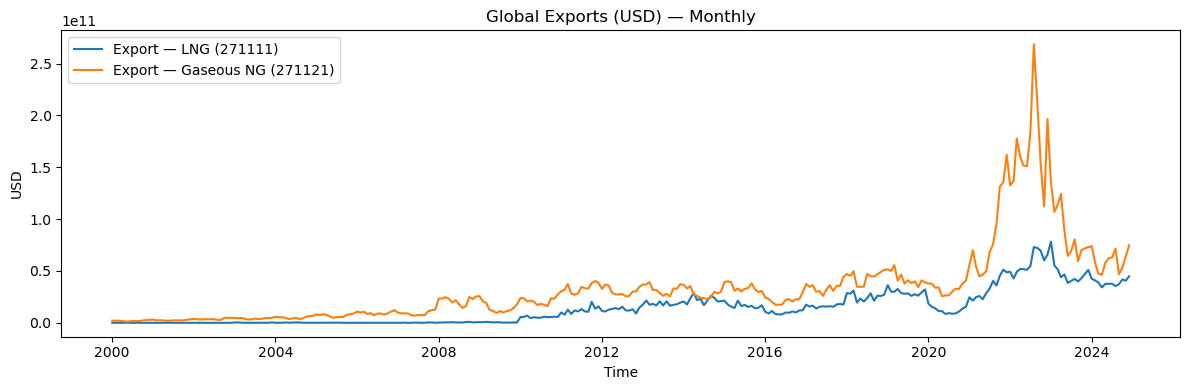

In [ ]:
# Same, but for export.
plt.figure(figsize=(12,4))
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = monthly_val_wide[monthly_val_wide["product"] == prod].sort_values("period")
    plt.plot(tmp["period"], tmp.get("Export", 0), label=f"Export — {prod}")

plt.title("Global Exports (USD) — Monthly")
plt.xlabel("Time")
plt.ylabel("USD")
plt.legend()
plt.tight_layout()
plt.show()





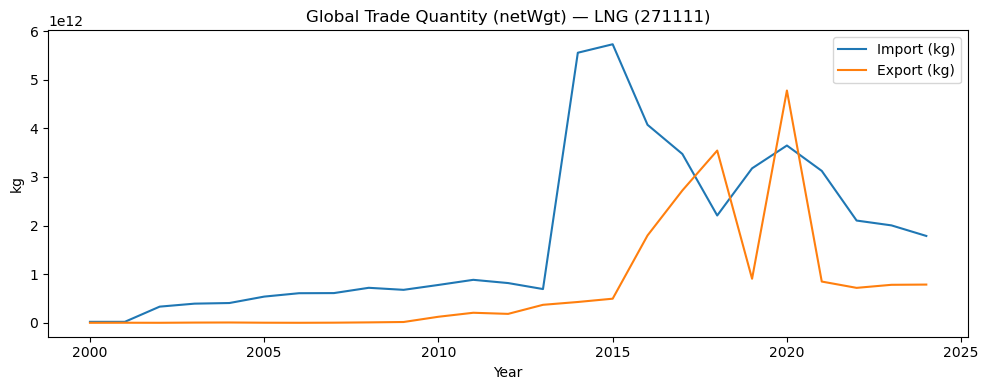

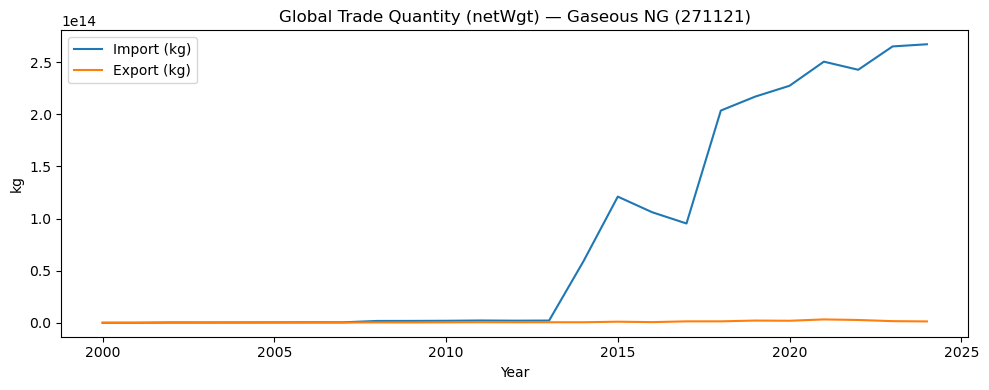

In [ ]:
# Analyzing the global trade quantity
annual_wgt = (
    df2.groupby(["refYear","flow_type","product"], as_index=False)
       .agg(weight_kg=("netWgt","sum"))
)

annual_wgt_piv = (
    annual_wgt.pivot_table(index=["refYear","product"], columns="flow_type", values="weight_kg", fill_value=0)
              .reset_index()
)

annual_wgt_piv["net_trade_kg"] = annual_wgt_piv.get("Export", 0) - annual_wgt_piv.get("Import", 0)

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    tmp = annual_wgt_piv[annual_wgt_piv["product"] == prod].sort_values("refYear")

    plt.figure(figsize=(10,4))
    plt.plot(tmp["refYear"], tmp.get("Import", 0), label="Import (kg)")
    plt.plot(tmp["refYear"], tmp.get("Export", 0), label="Export (kg)")
    plt.title(f"Global Trade Quantity (netWgt) — {prod}")
    plt.xlabel("Year")
    plt.ylabel("kg")
    plt.legend()
    plt.tight_layout()
    plt.show()


Please see the explaination of the above plots:
    1 - These plots confirm that the tarde value was not directly proportional to the total 'netWgt': 'net weight of commodity traded in kilograms'. 
        But we notice that UN comtrade reports imports more accurately than exports.

In [49]:
# annual_wgt_2024 = annual_wgt_piv[annual_wgt_piv["refYear"] == 2024]


# for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
#     tmp = annual_wgt_2024[annual_wgt_2024["product"] == prod]

#     imp = tmp.get("Import", 0).values[0]
#     exp = tmp.get("Export", 0).values[0]

#     print(f"\n{prod} — 2024")
#     print(f"Import (kg): {imp:,.0f}")
#     print(f"Export (kg): {exp:,.0f}")

#     plt.figure(figsize=(6,4))
#     plt.bar(["Import", "Export"], [imp, exp])
#     plt.title(f"Global Trade Quantity (netWgt) — {prod} (2024)")
#     plt.ylabel("kg")
#     plt.tight_layout()
#     plt.show()


## Continental and Country Specific analysis (Continent Leval Analysis)

Goal: This step identifies regional drivers of global gas demand, distinguishes LNG versus pipeline substitution by region, and shows which regions absorbed the 2022 shock and where LNG replaced pipeline gas.


In [90]:
"""
We mainly focus on imports only to obtain a clean, demand side perespective of natural gas trade. Import data asssign each shipment once and only once to the consuming region.
This avoids double counting and exporter side distortions. Additionally, In UN COMTRADE, imports are recorded cif (cost insurance and freight) while exports are fob (free on board).
This represents an overall difference, Despite all efforts made by national and international agencies, data quality may vary among countries.
For a given country, imports are usually recorded with more accuracy than exports because imports generally generate tariff revenues while exports don't.
At a detailed level, a same good may be recorded in different categories by the exporter and the importer.
"""

# Manual mapping of reporterCode to Continent, maintaing 5 continents for analysis

Africa = [
    12,   # Algeria
    24,   # Angola
    72,   # Botswana
    108,  # Burundi
    120,  # Cameroon
    132,  # Cape Verde
    148,  # Chad
    178,  # Congo
    180,  # DRC
    204,  # Benin
    231,  # Ethiopia
    262,  # Djibouti
    266,  # Gabon
    270,  # Gambia
    288,  # Ghana
    324,  # Guinea
    384,  # Côte d’Ivoire
    404,  # Kenya
    454,  # Malawi
    466,  # Mali
    504,  # Morocco
    516,  # Namibia
    562,  # Niger
    566,  # Nigeria
    646,  # Rwanda
    686,  # Senegal
    710,  # South Africa
    716,  # Zimbawe
    729,  # Sudan
    768,  # Togo
    788,  # Tunisia
    800,  # Uganda
    818   # Egypt
]

Americas = [
    32,   # Argentina
    68,   # Bolivia
    76,   # Brazil
    124,  # Canada
    152,  # Chile
    170,  # Colombia
    188,  # Costa Rica
    214,  # Dominican Republic
    218,  # Ecuador
    222,  # El Salvador
    320,  # Guatemala
    340,  # Honduras
    484,  # Mexico
    558,  # Nicaragua
    591,  # Panama
    600,  # Paraguay
    604,  # Peru
    740,  # Suriname
    858,  # Uruguay
    862,  # Venezuela
    840   # United States
]

Asia = [
    31,   # Azerbaijan
    48,   # Bahrain
    50,   # Bangladesh
    51,   # Armenia
    96,   # Brunei
    104,  # Myanmar
    116,  # Cambodia
    144,   # Sri Lanka
    156,  # China
    196,  # Cyprus 
    275,  # Palestine
    344,  # Hong Kong
    360,  # Indonesia
    364,  # Iran
    376,  # Israel
    392,  # Japan
    398,  # Kazakhstan
    400,  # Jordan
    410,  # South Korea
    414,  # Kuwait
    417,  # Kyrgyzstan
    458,  # Malaysia
    496,  # Mongolia
    512,  # Oman
    524,  # Nepal
    586,  # Pakistan
    608,  # Philippines
    634,  # Qatar
    682,  # Saudi Arabia
    699,  # India
    702,  # Singapore
    704,  # Vietnam
    764,  # Thailand
    784,  # United Arab Emirates
    792,  # Turkey
    860,  # Uzbekistan
    887   # Yemen
]

Europe = [
    8,    # Albania
    40,   # Austria
    56,   # Belgium
    100,  # Bulgaria
    112,  # Belarus
    191,  # Croatia
    203,  # Czech Republic
    208,  # Denmark
    233,  # Estonia
    246,  # Finland
    251,  # France
    276,  # Germany
    300,  # Greece
    348,  # Hungary
    352,  # Iceland
    372,  # Ireland
    380,  # Italy
    428,  # Latvia
    440,  # Lithuania
    442,  # Luxembourg
    470,  # Malta
    499,  # Montenegro
    528,  # Netherlands
    579,  # Norway
    616,  # Poland
    620,  # Portugal
    642,  # Romania
    643,  # Russian Federation
    688,  # Serbia
    703,  # Slovakia
    705,  # Slovenia
    724,  # Spain
    752,  # Sweden
    757,  # Switzerland
    804,  # Ukraine
    807,  # North Macedonia
    826   # United Kingdom
]

Oceania = [
    36,   # Australia
    554,  # New Zealand
    598   # Papua New Guinea
]

continent_map = {
    "Africa": Africa,
    "Americas": Americas,
    "Asia": Asia,
    "Europe": Europe,
    "Oceania": Oceania
}


reporter_to_continent = {
    code: cont
    for cont, codes in continent_map.items()
    for code in codes
}

# Assign continent
df3 = df2.copy()
df3["continent"] = df3["reporterCode"].map(reporter_to_continent)

# Check coverage
coverage = df3["continent"].value_counts(dropna=False)
coverage


# unmapped_codes = (
#     df2.loc[~df2["reporterCode"].isin(reporter_to_continent.keys()),
#             "reporterCode"]
#     .unique()
# )

# print("Unmapped reporter codes:", unmapped_codes)

# Check if any reporterCode in your dataset is unmapped
# unmapped = (
#     df2[~df2["reporterCode"].isin(reporter_to_continent.keys())]
#     ["reporterCode"]
#     .nunique()
# )

# print("Unmapped reporter codes:", unmapped)



continent
Europe      317712
Asia         52870
NaN          44690
Africa       43027
Americas     32366
Oceania       1141
Name: count, dtype: int64

In [ ]:
# Analyzing Continental imports
imports_cont = df3[df3["flow_type"] == "Import"].copy()

# Aggregate annual imports by continent and product
annual_cont_val = (
    imports_cont
    .groupby(["refYear", "continent", "product"], as_index=False)
    .agg(
        value_usd=("primaryValue", "sum"),
        weight_kg=("netWgt", "sum")
    )
)

annual_cont_val.head()

annual_cont_val.groupby("continent")[["value_usd", "weight_kg"]].sum().sort_values(by=["value_usd", "weight_kg"], ascending=False)



,value_usd,weight_kg
continent,,
Europe,2.642111e+13,6.010063e+13
Asia,4.641577e+12,8.606263e+12
Americas,1.300914e+12,2.045513e+15
Africa,1.170137e+11,4.591781e+11
Oceania,1.738257e+10,3.094613e+10


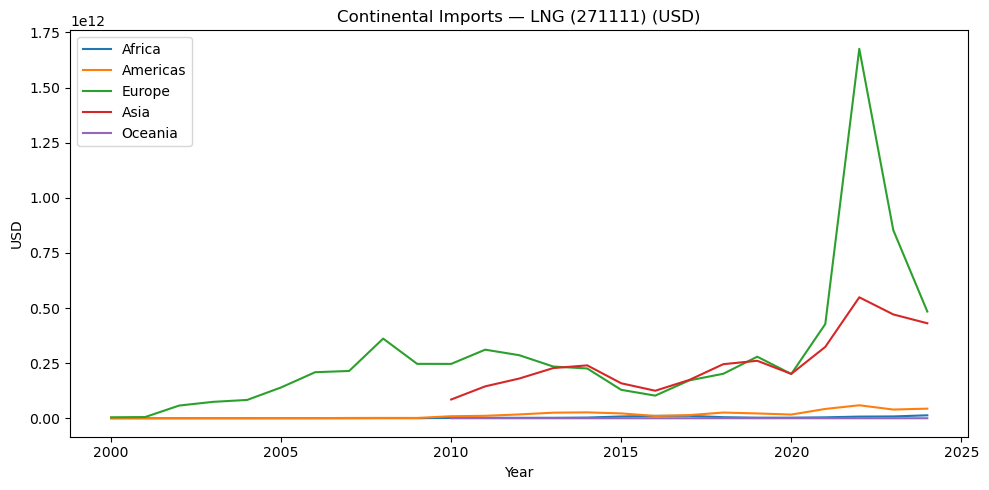

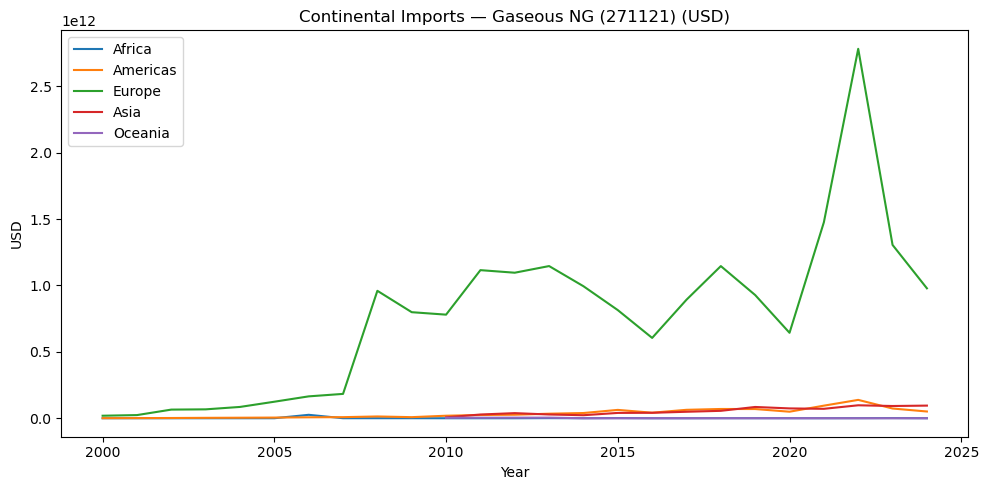

In [75]:
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plt.figure(figsize=(10,5))
    tmp = annual_cont_val[annual_cont_val["product"] == prod]

    for cont in tmp["continent"].unique():
        sub = tmp[tmp["continent"] == cont].sort_values("refYear")
        plt.plot(sub["refYear"], sub["value_usd"], label=cont)

    plt.title(f"Continental Imports — {prod} (USD)")
    plt.xlabel("Year")
    plt.ylabel("USD")
    plt.legend()
    plt.tight_layout()
    plt.show()


Please find explanations of the above plot:

1 - LNG import values increase steadily over time, with Asia and Europe emerging as the dominant importing regions. A pronounced spike in European LNG imports in 2022 reflects crisis-driven substitution away from pipeline gas combined with extreme global price increases.

2 - Pipeline natural gas imports are concentrated in Europe throughout the sample period. There is a sharp increase in 2022, followed by a rapid decline, indicating a price-driven shock and subsequent disruption of pipeline-based supply.

Note: Continental import values represent aggregated customs-reported trade flows and should be interpreted as indicators of trade intensity rather than net regional gas expenditure.


In [78]:
share_df = annual_cont_val.copy()

# Total imports per year & product
share_df["total_value"] = (
    share_df
    .groupby(["refYear", "product"])["value_usd"]
    .transform("sum")
)

# Share of each continent
share_df["share"] = share_df["value_usd"] / share_df["total_value"]

share_df.head()

,refYear,continent,product,value_usd,weight_kg,total_value,share
0,2000,Africa,Gaseous NG (271121),1.047873e+05,4.617920e+05,1.967518e+10,0.000005
1,2000,Africa,LNG (271111),3.328020e+05,1.045816e+06,4.395733e+09,0.000076
2,2000,Americas,Gaseous NG (271121),6.565699e+08,5.973975e+09,1.967518e+10,0.033370
3,2000,Americas,LNG (271111),1.549640e+05,1.040855e+06,4.395733e+09,0.000035
4,2000,Europe,Gaseous NG (271121),1.901851e+10,1.326205e+11,1.967518e+10,0.966624


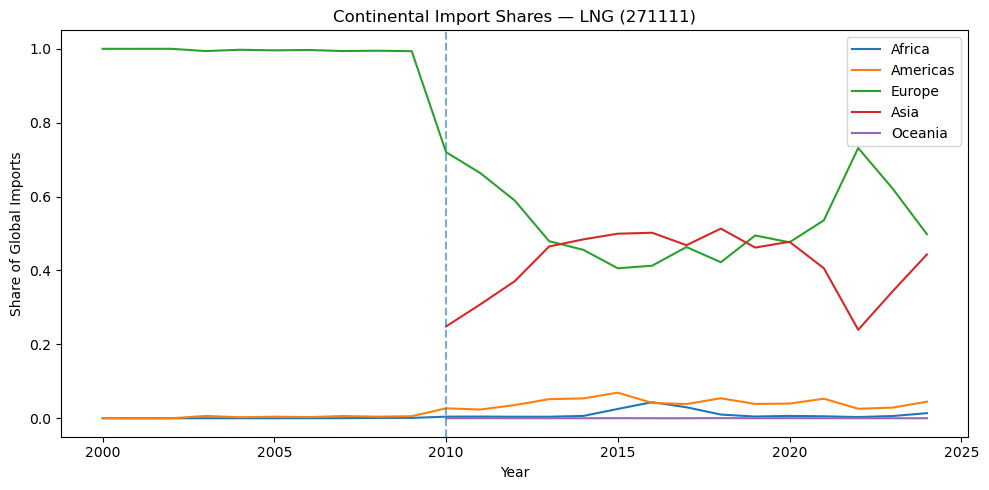

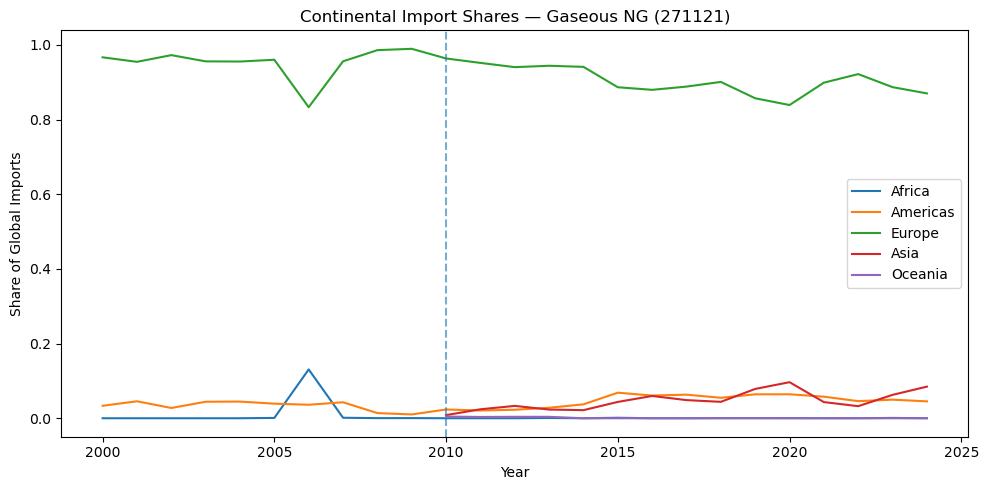

In [83]:

for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plt.figure(figsize=(10,5))
    tmp = share_df[share_df["product"] == prod]

    for cont in tmp["continent"].unique():
        sub = tmp[tmp["continent"] == cont].sort_values("refYear")
        plt.plot(sub["refYear"], sub["share"], label=cont)

    plt.title(f"Continental Import Shares — {prod}")
    plt.xlabel("Year")
    plt.ylabel("Share of Global Imports")
    plt.legend()
    plt.tight_layout()
    plt.axvline(2010, linestyle="--", alpha=0.6)

    plt.show()
    

Please find explanations of above plot:

1 - Before 2010, LNG import shares should be interpreted with caution due to limited reporting coverage. From 2010 onward, Asia and Europe dominate global LNG imports. A sharp increase in Europe’s share in 2022 highlights crisis-driven LNG substitution following disruptions to pipeline gas supply.

2 - Pipeline natural gas imports are consistently dominated by Europe throughout the sample period, reflecting fixed pipeline infrastructure and geographical proximity. The decline in Europe’s share after 2022 indicates a structural contraction of pipeline-based imports during the energy crisis, accompanied by modest increases in Asia’s share.

Note: The dashed line at 2010 marks the start of more comprehensive LNG reporting.

<Figure size 1000x500 with 0 Axes>

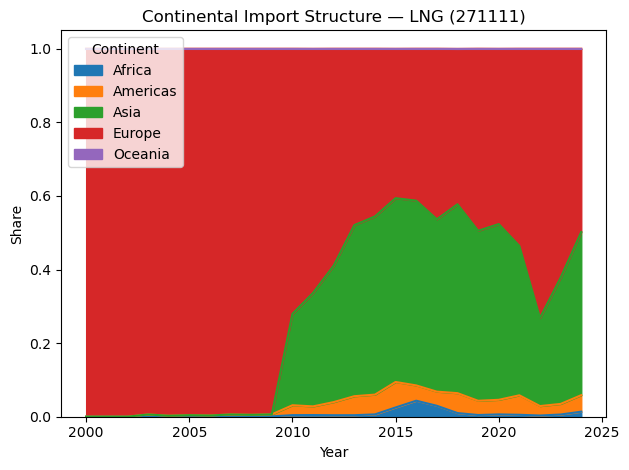

<Figure size 1000x500 with 0 Axes>

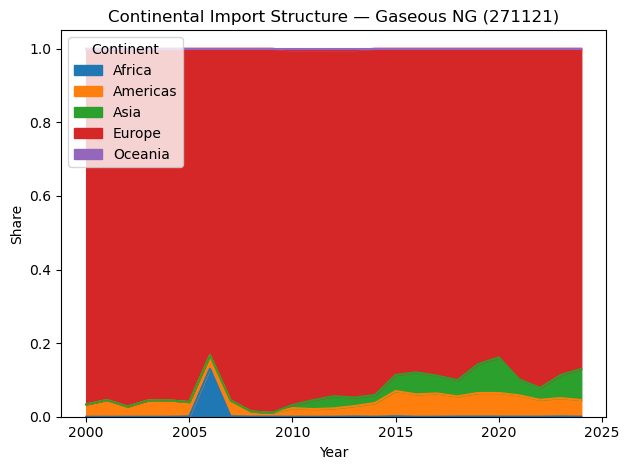

In [80]:
for prod in ["LNG (271111)", "Gaseous NG (271121)"]:
    plt.figure(figsize=(10,5))
    tmp = (
        share_df[share_df["product"] == prod]
        .pivot(index="refYear", columns="continent", values="share")
        .fillna(0)
        .sort_index()
    )

    tmp.plot.area()
    plt.title(f"Continental Import Structure — {prod}")
    plt.xlabel("Year")
    plt.ylabel("Share")
    plt.legend(title="Continent", loc="upper left")
    plt.tight_layout()
    plt.show()


In [89]:
# Country level analysis next
